[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5512-labs/blob/master/Module1/Week1_TechStack/Lab1_FirstCommit/notebooks/Lab1_B_Demand_Starter.ipynb)

# Lab 1 - Partner B: the demand half

**You own this notebook and `src/clean_demand.py`. Partner A never touches either one.**

Your job tonight:
1. Load the raw ISO-NE demand report
2. Turn it into a tidy **hourly** table
3. Make one plot
4. Save `data/clean/demand_hourly.csv` and get it into the repo on branch `dev-demand`

You are **not** doing the weather side, and you are not doing the join. You physically cannot
finish the story alone - that is the point of the lab.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Where the class data lives on GitHub. "raw" = give me the file, not the web page.
RAW = ("https://raw.githubusercontent.com/drdave-teaching/OPIM5512-labs/master/"
       "Module1/Week1_TechStack/Lab1_FirstCommit/data")

# CHANGE THIS to your campus: "hartford" (KBDL) or "stamford" (KBDR)
CAMPUS  = "hartford"
STATION = {"hartford": "KBDL", "stamford": "KBDR"}[CAMPUS]

print("Campus:", CAMPUS, "| Airport:", STATION)

Campus: hartford | Airport: KBDL


## 1. Look before you parse

This file will punish you for skipping this step. Print the raw lines first.

In [2]:
import urllib.request
url = f"{RAW}/isone_demand_hourly_raw.csv"
print(urllib.request.urlopen(url).read(500).decode())

"C","Real-Time Hourly System Load Report"
"C","Filename: rt_hourlysysload_20260720_20260819.csv"
"C","Report for: 07/20/2026 - 08/19/2026"
"C","Report generated: 08/20/2026 10:38:14 EDT"
"H","Date","Hour Ending","Total Load"
"H","Date","HE","MWh"
"D","07/20/2026","01",12158.9
"D","07/20/2026","02",11672.76
"D","07/20/2026","03",11458.13
"D","07/20/2026","04",11083.58
"D","07/20/2026","05",11088.35
"D","07/20/2026","06",11357.97
"D","07/20/2026","07",11503.01
"D","07/20/2026","08",11759.17
"D","0


## 2. The format

This is a real ISO-NE report, exactly as it downloads. **Every line starts with a tag:**

| Tag | Meaning |
|---|---|
| `"C"` | comment — title, filename, dates (**4 lines**) |
| `"H"` | header — **two** of them (names, then units) |
| `"D"` | data — the 744 rows you actually want |
| `"T"` | a **summary footer** at the very end |

So your data is sandwiched: **6 header lines on top, 1 summary line on the bottom.** Two easy
moves handle it — **skip the 6 header lines**, then **keep only the `"D"` rows** (that also drops
the footer). The next cell does exactly that.

> 🔧 **Module 3 preview:** a pro *filters on the tag* instead of hard-coding `skiprows=6`,
> because the day ISO-NE adds one comment line, a fixed skip count silently breaks. That kind of
> robustness is what Module 3 is about — tonight, skip-then-filter is plenty.

The `Hour Ending` column is **1–24, not 0–23**. **Hour Ending 01 is the hour that ran from
00:00 to 01:00.** Getting this wrong shifts your entire series by an hour, and it will not be
obvious until you join to weather and the correlation looks strange. This is one of the most
common real-world energy-data bugs.

In [3]:
# Read the file. Two moves handle the header-and-footer sandwich:
#   1. skiprows=6      -> drop the 6 header lines at the top
#   2. keep tag == "D" -> keep only the real data rows (also drops the "T" footer)
# header=None + names=[...] : there's no clean header left, so we name the columns ourselves.
demand = pd.read_csv(url, skiprows=6, header=None,
                     names=["tag", "date", "hour_ending", "load_mw"])
demand = demand[demand["tag"] == "D"].reset_index(drop=True)

print(demand.shape)   # (744, 4)
demand.head()

(744, 4)


,tag,date,hour_ending,load_mw
0,D,07/20/2026,1.0,12158.90
1,D,07/20/2026,2.0,11672.76
2,D,07/20/2026,3.0,11458.13
3,D,07/20/2026,4.0,11083.58
4,D,07/20/2026,5.0,11088.35


## 3. Build a real timestamp

Turn `date` + `hour_ending` into a single timestamp column called `hour` that represents the
**start** of the hour - so it will line up with Partner A's weather observations.

Think carefully: if `date = 07/20/2026` and `hour_ending = 01`, what is the starting hour?

In [14]:
demand['my_date'] = pd.to_datetime(demand['date'])
# Calculate the hour component (0-23) from 'hour_ending' (1-24)
demand["hour_component"] = demand["hour_ending"].astype(int) - 1

# Combine 'my_date' and 'hour_component' to create the final 'hour' timestamp
demand["hour"] = demand.apply(lambda row: row['my_date'] + pd.to_timedelta(row['hour_component'], unit='h'), axis=1)

demand.dtypes
demand.head()

# TODO: produce `hourly` with exactly two columns:
#   - `hour`  the timestamp
#   - the load, named the way YOUR CONTRACT says
# sorted by hour, with the index reset.
hourly = demand[['hour', 'load_mw']].rename(columns={'load_mw': 'load_mw'})
hourly = hourly.sort_values('hour').reset_index(drop=True)

print(len(hourly), "hours")   # should be 744
hourly.head()

744 hours


,hour,load_mw
0,2026-07-20 00:00:00,12158.90
1,2026-07-20 01:00:00,11672.76
2,2026-07-20 02:00:00,11458.13
3,2026-07-20 03:00:00,11083.58
4,2026-07-20 04:00:00,11088.35


In [ ]:
# TODO: sanity check. What are the min, max and mean load in MW?
# For context: New England's all-time record is about 28,130 MW, set on August 2, 2006.


## 4. One plot

Plot demand over the month. Then plot the **average demand by hour of day**. The second one is
the more interesting picture - the grid has a heartbeat.

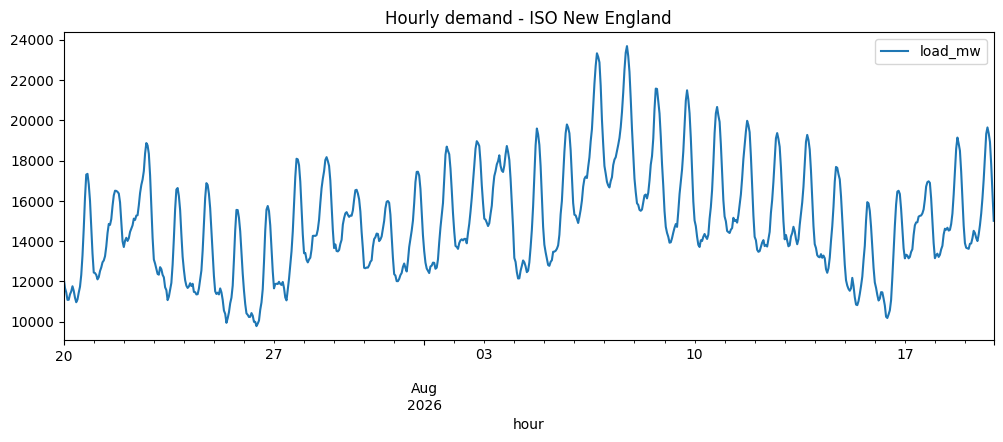

In [15]:
# TODO: plot demand over the month, then SAVE the figure to a file.

# Plot against TIME, not the row number - the question is WHEN.
ax = hourly.plot(x='hour', y='load_mw', figsize=(12, 4),
                 title='Hourly demand - ISO New England')

# Save the picture so you can commit it to the repo (it goes under images/):
ax.get_figure().savefig('monthly_demand.png', bbox_inches='tight', dpi=120)
# Looking at a plot is not the same as saving one - the file is the deliverable.

# Bonus: also plot AVERAGE demand by hour of day (0-23). The grid has a heartbeat.

## 5. Save it and get it into the repo

**This is the part that matters tonight.** Colab's disk is temporary - the file below
disappears when the runtime disconnects. Getting it into the repo is a deliberate act.

In [ ]:
hourly.to_csv("demand_hourly.csv", index=False)

from google.colab import files
files.download("demand_hourly.csv")    # -> repo:  data/clean/demand_hourly.csv
files.download("monthly_demand.png")   # -> repo:  images/monthly_demand.png

Now, off Colab. Three things end up in your repo:

| File | Where it goes in the repo |
|---|---|
| `demand_hourly.csv` | `data/clean/demand_hourly.csv` |
| `monthly_demand.png` | `images/monthly_demand.png` |
| the notebook itself | repo **root** — keep its filename |

**Your notebook — two ways in (pick one):**
- **Option A — straight from Colab:** **File → Save** → your repo, branch `dev-demand`,
  filename at the root, real commit message. (Plain Save commits to GitHub because you opened
  this *from* GitHub. This is the "move a notebook both directions" skill.)
- **Option B — download & drag:** **File → Download → Download .ipynb**, then drag it into your
  repo folder like any other file — no Colab↔GitHub dialog to fight.

> Either way, **Restart and run all**, then **Clear all outputs** *before* it goes in.

**Then get your files into the repo — this all happens through GitHub Desktop:**
1. In **GitHub Desktop**, click **Repository → Show in Explorer** (Windows) / **Reveal in
   Finder** (Mac). That opens your repo's actual folder on your laptop — the one you drag into.
2. Drag your downloads in from your **Downloads** folder:
   - `demand_hourly.csv` → into **`data/clean/`**
   - `monthly_demand.png` → into **`images/`**
   - *(Option B only)* the `.ipynb` → into the repo **root**

   Make the `data/clean/` and `images/` folders first if they aren't there yet.
3. Back in **GitHub Desktop**, your files appear under **Changes**. Confirm you're on branch
   **`dev-demand`** (top of the window!), commit with a real message, then **Push**.
4. On github.com: **Compare & pull request**. Ask Partner A to review it.

> If Desktop says you're on `main`, stop and switch branches first — `main` is protected and
> will reject the push (the protection working, not a bug). If you used Option A, Desktop may
> ask you to **Pull** before pushing — that's just your notebook coming back down from GitHub.

### Then write your half of the data dictionary
In the repo `README.md`, document **every column** in `demand_hourly.csv`: name, meaning,
units, and — importantly — **what timestamp convention you chose** and why. Partner A is
documenting theirs at the same time, in the same file. Yes, that is going to collide.